In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import friedmanchisquare
import glob
import openpyxl

In [3]:
import pandas as pd
import glob

files = glob.glob("cnn_text/*.csv")   # example pattern

dfs = []
for f in files:
    df = pd.read_csv(f)

    # infer model name from filename
    model_name = f.replace(".csv","").replace("results_","")
    df["Model"] = model_name

    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

# sort
df_all = df_all.sort_values("mean_macro_f1", ascending=False)

df_all.to_excel("combined_cleaned_sorted_with_model.xlsx", index=False)

print("Combined file saved ✔")


Combined file saved ✔


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_all = pd.read_excel("combined_cleaned_sorted_with_model.xlsx")

# --- 1. Best model per language ---
best_model_per_lang = df_all.loc[
    df_all.groupby('language')['mean_macro_f1'].idxmax()
]

print("Best model per language:\n",
      best_model_per_lang[['language','Model','mean_macro_f1']])

# --- 2. Summary statistics per model ---
model_summary = (
    df_all.groupby('Model')[['mean_acc','mean_macro_f1']]
    .mean()
    .sort_values('mean_macro_f1', ascending=False)
)

print("\nAverage performance per model:\n", model_summary)

# --- 3. Pivot table ---
pivot_f1 = df_all.pivot(
    index='language',
    columns='Model',
    values='mean_macro_f1'
)

print("\nMean Macro F1 per language per model:\n", pivot_f1)


Best model per language:
    language               Model  mean_macro_f1
50      amh  cnn_text\jiina_cnn       0.713078
19      arb  cnn_text\jiina_cnn       0.780642
8       ben     cnn_text\e5_cnn       0.805398
71      deu  cnn_text\labse_cnn       0.651343
26      eng     cnn_text\e5_cnn       0.753674
20      fas    cnn_text\bge_cnn       0.778421
43      hau  cnn_text\labse_cnn       0.721661
40      hin  cnn_text\jiina_cnn       0.723958
88      ita    cnn_text\bge_cnn       0.592194
80      khm     cnn_text\e5_cnn       0.621720
13      mya  cnn_text\jiina_cnn       0.799403
0       nep  cnn_text\jiina_cnn       0.836246
18      ori  cnn_text\jiina_cnn       0.783362
58      pan    cnn_text\bge_cnn       0.697267
31      pol  cnn_text\jiina_cnn       0.740094
49      rus  cnn_text\jiina_cnn       0.713219
55      spa  cnn_text\jiina_cnn       0.708258
38      swa  cnn_text\labse_cnn       0.727479
1       tel     cnn_text\e5_cnn       0.832879
30      tur  cnn_text\jiina_cnn   

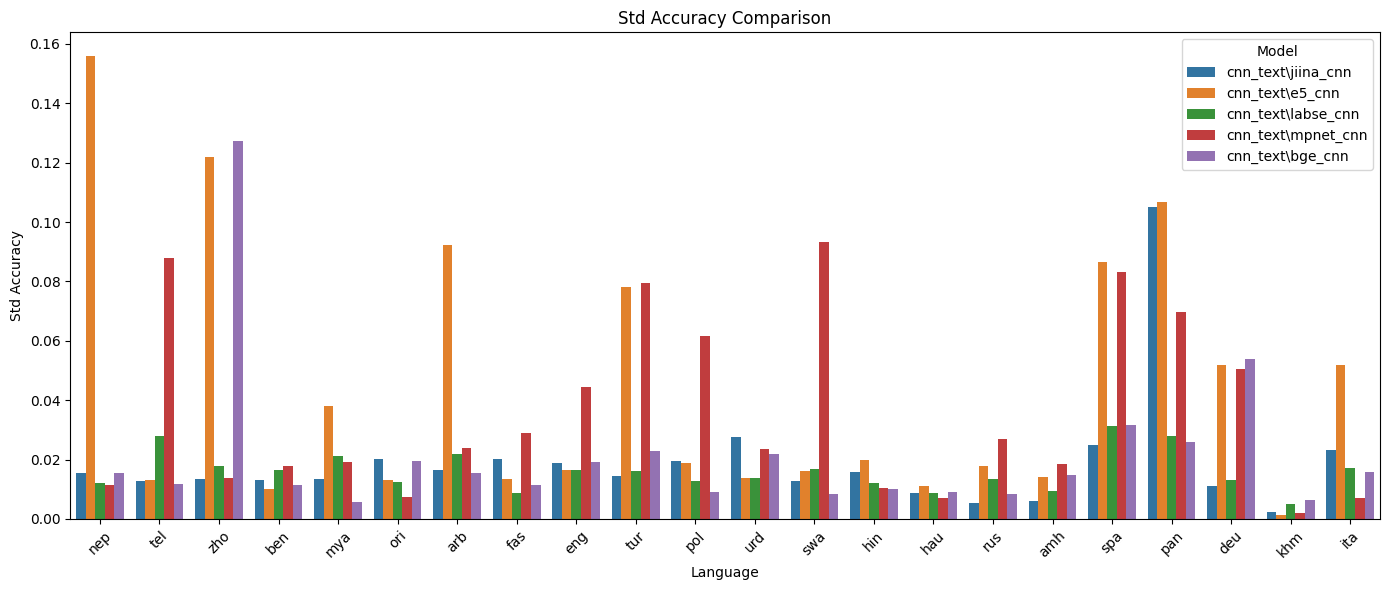

In [8]:
plt.figure(figsize=(14,6))
sns.barplot(x='language', y='std_acc', hue='Model', data=df_all)
plt.title('Std Accuracy Comparison')
plt.ylabel('Std Accuracy')
plt.xlabel('Language')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


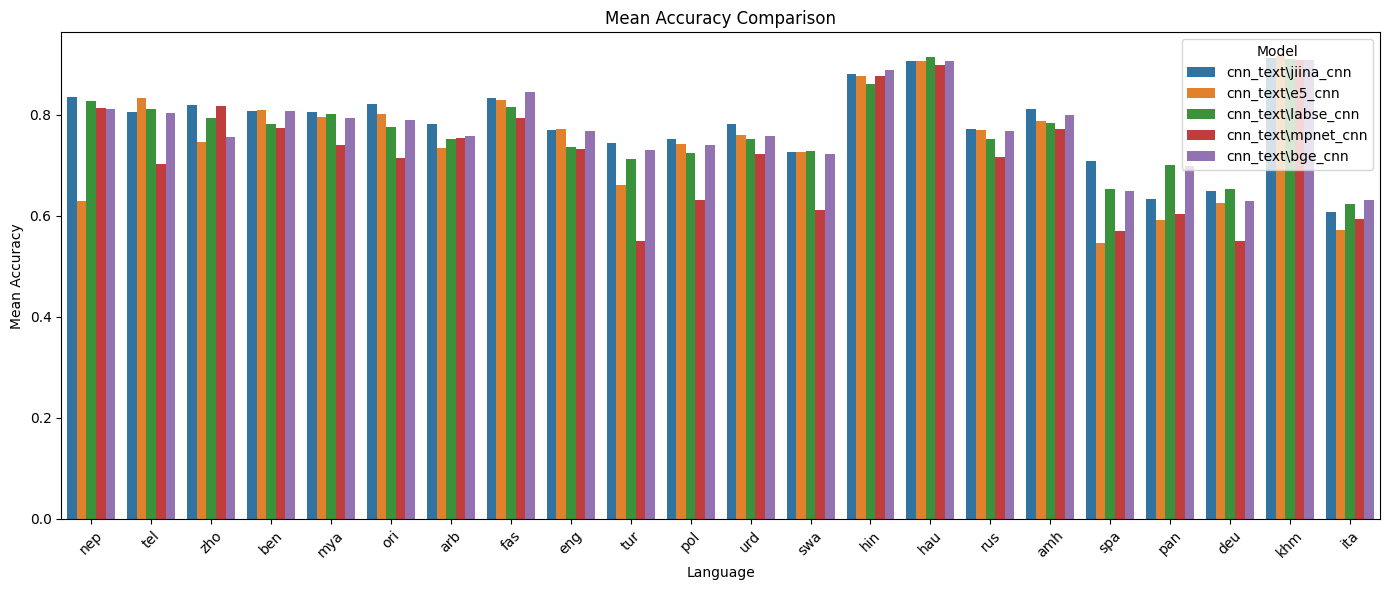

In [9]:
plt.figure(figsize=(14,6))
sns.barplot(x='language', y='mean_acc', hue='Model', data=df_all)
plt.title('Mean Accuracy Comparison')
plt.ylabel('Mean Accuracy')
plt.xlabel('Language')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


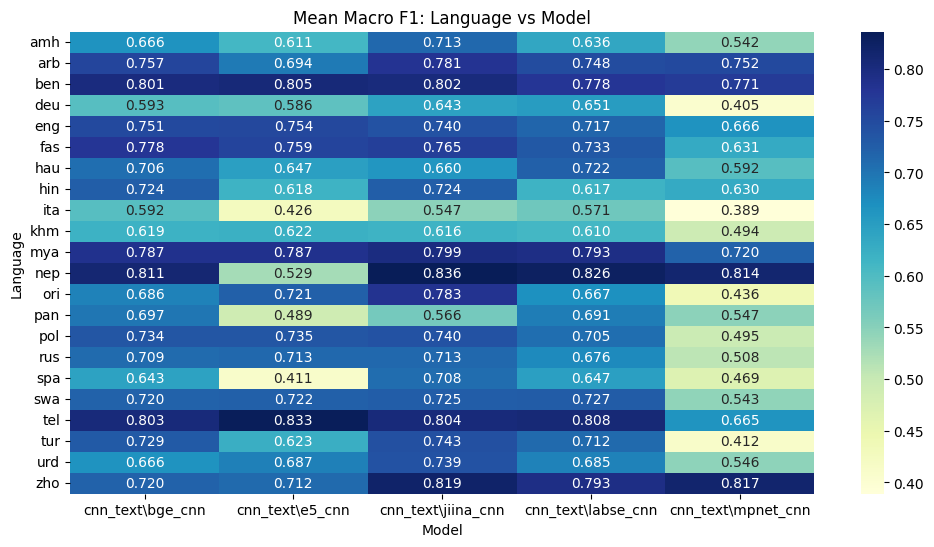

In [10]:
plt.figure(figsize=(12,6))
sns.heatmap(pivot_f1, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("Mean Macro F1: Language vs Model")
plt.ylabel("Language")
plt.xlabel("Model")
plt.show()
